<a href="https://colab.research.google.com/github/LewisT1424/010-MOD006902/blob/main/Week_1/Section_10_Python_Example__Analyzing_a_Dataset_Relevant_to_Your_Field.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Python Example: Analyzing a Dataset Relevant to Your Field

This section demonstrates a practical Python example of data analysis, specifically designed for data scientists who might be working in the retail sector. This example will walk through the process of loading data, performing exploratory data analysis (EDA), building a simple predictive model, and interpreting the results. The focus will be on analysing customer purchase data to identify patterns and predict future buying behaviors, using Python libraries such as Pandas for data manipulation and Scikit-learn for modeling.

1. Loading and Inspecting the Data:

We'll start by loading a dataset containing customer purchases from a retail store. The dataset includes customer demographics and purchase history. We will use Pandas, a powerful data manipulation library in Python, to load and inspect our dataset.

In [14]:
import polars as pl

data = pl.read_csv('customer_purchases.csv')

print(data.shape)
print(data.head(5))
print(data.describe())

(1000, 4)
shape: (5, 4)
┌─────────────┬─────┬───────────────┬─────────────────────┐
│ customer_id ┆ age ┆ last_purchase ┆ will_purchase_again │
│ ---         ┆ --- ┆ ---           ┆ ---                 │
│ i64         ┆ i64 ┆ str           ┆ str                 │
╞═════════════╪═════╪═══════════════╪═════════════════════╡
│ 1           ┆ 56  ┆ Home & Garden ┆ no                  │
│ 2           ┆ 69  ┆ Home & Garden ┆ yes                 │
│ 3           ┆ 46  ┆ Electronics   ┆ yes                 │
│ 4           ┆ 32  ┆ Sports        ┆ no                  │
│ 5           ┆ 60  ┆ Beauty        ┆ no                  │
└─────────────┴─────┴───────────────┴─────────────────────┘
shape: (9, 5)
┌────────────┬─────────────┬───────────┬───────────────┬─────────────────────┐
│ statistic  ┆ customer_id ┆ age       ┆ last_purchase ┆ will_purchase_again │
│ ---        ┆ ---         ┆ ---       ┆ ---           ┆ ---                 │
│ str        ┆ f64         ┆ f64       ┆ str           ┆ str     

2. Data Cleaning:

Data cleaning is a crucial step before any analysis. We'll clean the data by handling missing values, removing duplicates, and converting data types if necessary.

In [15]:
# Remove nulls
data = data.filter(
  pl.col('age').is_not_null(),
  pl.col('last_purchase').is_not_null()
)

# Turn binary column into 1 & 0
data = data.with_columns(
    pl.when(pl.col('will_purchase_again') == 'no')
    .then(pl.lit(0)).otherwise(1).alias('will_purchase_again')
)

In [20]:
data = data.with_columns(
    pl.col('last_purchase').rank('dense').cast(pl.Int64).alias('last_purchase_encoded')
)

3. Exploratory Data Analysis (EDA):

In [21]:
data.head()

customer_id,age,last_purchase,will_purchase_again,last_purchase_encoded
i64,i64,str,i32,i64
1,56,"""Home & Garden""",0,4
2,69,"""Home & Garden""",1,4
3,46,"""Electronics""",1,3
4,32,"""Sports""",0,5
5,60,"""Beauty""",0,1


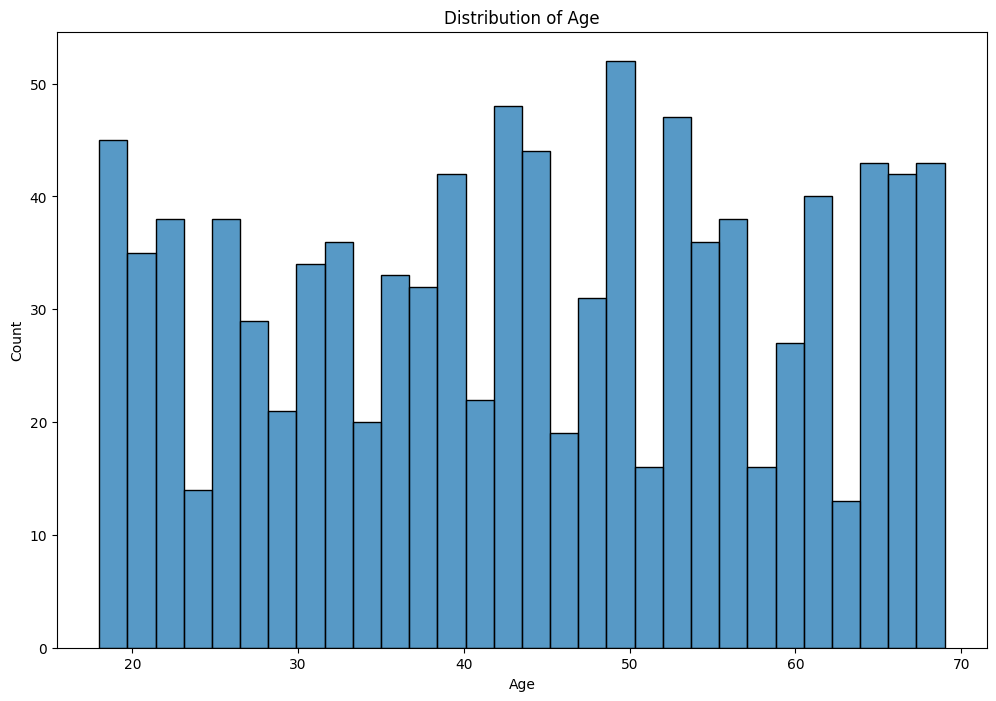

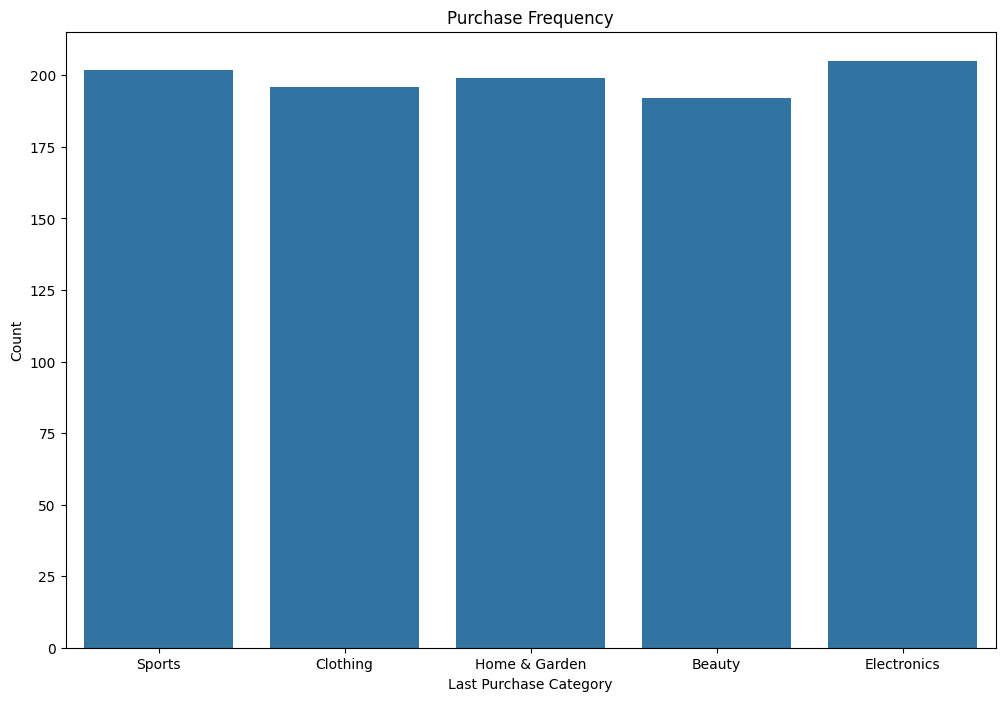

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplots(figsize=(12,8))
sns.histplot(data['age'], bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count');

purchase_freq = data.group_by('last_purchase').agg([pl.len().alias('n')])
plt.figure(figsize=(12,8))
sns.barplot(x=purchase_freq['last_purchase'], y=purchase_freq['n'])
plt.title('Purchase Frequency')
plt.xlabel('Last Purchase Category')
plt.ylabel('Count');

EDA involves summarizing the main characteristics of the dataset, often with visual methods. We'll use Pandas for data manipulation and Matplotlib for visualization.

4. Building a Predictive Model:

We'll use a simple logistic regression model to predict whether a customer will make a purchase in a specific category based on their age and last purchase category. Scikit-learn is a library that provides simple and efficient tools for data mining and data analysis.

In [30]:
data.head()

customer_id,age,last_purchase,will_purchase_again,last_purchase_encoded
i64,i64,str,i32,i64
1,56,"""Home & Garden""",0,4
2,69,"""Home & Garden""",1,4
3,46,"""Electronics""",1,3
4,32,"""Sports""",0,5
5,60,"""Beauty""",0,1


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = data[['age', 'last_purchase_encoded']]
y = data['will_purchase_again']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy", accuracy_score(y_test, y_pred))

Accuracy 0.48743718592964824


5. Interpreting the Results:

The final step is to interpret the results of our logistic regression model. An accuracy metric will tell us how often the model predicts correctly. Further interpretation might involve looking at the coefficients of the model to understand the impact of different features on the likelihood of a customer making a purchase.